In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
from scipy.stats import uniform, norm, multivariate_normal
import seaborn as sns 
import multiprocessing as mp
from functools import partial
import time
import copy
import glob
import warnings
warnings.filterwarnings('ignore')
import arviz as az
import pymc as pm
#from main_pool import Main
#from calibr_funcs import plot_results
import calibr_funcs
from networks.model_output import SEIRModelOutput, SEIRParams
from networks.SEIR_network import SEIRNetworkModel

from hybrid_network_to_seir import NetworkSEIR_tuned,\
                                    generate_synthetic_data

#pip install -e git+https://github.com/Mpkosh/Mathematics-of-Epidemics-on-Networks.git@my_changes#egg=eon

import plot_funcs
import plot_hyb
import predict_Beta_I
import seir_discrete
import choice_start_day
%load_ext autoreload
%autoreload 2

pm.__version__  

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


'5.25.1'

In [17]:
# generate synthetic data with known parameters for testing
true_tau = 0.1
true_alpha = 0.95
init_inf = 0.0001
gamma = 0.3 # latent period rate
delta = 0.2 # recovery rate

days=range(1, 150)
data_p = 'new_network_check/'
'''
observed_data = generate_synthetic_data(alpha=true_alpha, lmbd=true_lmbd, 
                                        days=days, data_path=data_p,
                                       with_seirb=True, with_switch=False,
                                       for_observed=True)
'''

'''
self.G = nx.barabasi_albert_graph(population=10**5, 5)
gamma = 0.3 # latent period rate
delta = 0.2 # recovery rate
init_inf_frac = 1e-4 # fraction of initially infected

alpha = 0.95
beta = 0.1
'''


'\nself.G = nx.barabasi_albert_graph(population=10**5, 5)\ngamma = 0.3 # latent period rate\ndelta = 0.2 # recovery rate\ninit_inf_frac = 1e-4 # fraction of initially infected\n\nalpha = 0.95\nbeta = 0.1\n'

In [18]:
pot = glob.glob('../new_sw_100000/'+
            f'p_{true_tau}_{gamma}_{delta}_{init_inf}_{true_alpha}*')

pot

['../new_sw_100000\\p_0.1_0.3_0.2_0.0001_0.9500000000000006_seed_0.csv',
 '../new_sw_100000\\p_0.1_0.3_0.2_0.0001_0.9500000000000006_seed_1.csv',
 '../new_sw_100000\\p_0.1_0.3_0.2_0.0001_0.9500000000000006_seed_2.csv',
 '../new_sw_100000\\p_0.1_0.3_0.2_0.0001_0.9500000000000006_seed_3.csv',
 '../new_sw_100000\\p_0.1_0.3_0.2_0.0001_0.9500000000000006_seed_4.csv',
 '../new_sw_100000\\p_0.1_0.3_0.2_0.0001_0.9500000000000006_seed_5.csv',
 '../new_sw_100000\\p_0.1_0.3_0.2_0.0001_0.9500000000000006_seed_6.csv',
 '../new_sw_100000\\p_0.1_0.3_0.2_0.0001_0.9500000000000006_seed_7.csv',
 '../new_sw_100000\\p_0.1_0.3_0.2_0.0001_0.9500000000000006_seed_8.csv',
 '../new_sw_100000\\p_0.1_0.3_0.2_0.0001_0.9500000000000006_seed_9.csv']

In [46]:
path = '../new_sw_100000\\p_0.5799999999999997_0.3_0.2_0.0001_0.8000000000000005_seed_0.csv'
seed_df = pd.read_csv(path, usecols=['E','S'])
# calculating incidence
temp = seed_df[['E','S']].shift([0,1])
seed_df['incidence'] = (temp['E_1'] - temp['E_0']) - \
                    (temp['S_0'] - temp['S_1'])
seed_df['incidence'].fillna(0, inplace=True)
seed_df

,S,E,incidence
0,79991,0,0.0
1,79990,1,0.0
2,79988,3,0.0
3,79987,2,2.0
4,79981,4,4.0
...,...,...,...
145,4069,160,54.0
146,4044,139,46.0
147,4014,125,44.0
148,3993,113,33.0


In [49]:
#seed_df[['incidence']].to_csv('incidence_sw.csv', 
                             index=False)


In [128]:
q = glob.glob('../new_sw_100000/*.csv')[::10]
import random
random.seed(42)
random.sample(q,10)

['../new_sw_100000\\p_0.7499999999999997_0.3_0.2_0.0001_0.5800000000000003_seed_0.csv',
 '../new_sw_100000\\p_0.20999999999999996_0.3_0.2_0.0001_0.5200000000000002_seed_0.csv',
 '../new_sw_100000\\p_0.13999999999999999_0.3_0.2_0.0001_0.6400000000000003_seed_0.csv',
 '../new_sw_100000\\p_0.8499999999999996_0.3_0.2_0.0001_0.9400000000000006_seed_0.csv',
 '../new_sw_100000\\p_0.3799999999999999_0.3_0.2_0.0001_0.3300000000000001_seed_0.csv',
 '../new_sw_100000\\p_0.34999999999999987_0.3_0.2_0.0001_0.2700000000000001_seed_0.csv',
 '../new_sw_100000\\p_0.3199999999999999_0.3_0.2_0.0001_0.8800000000000006_seed_0.csv',
 '../new_sw_100000\\p_0.23999999999999994_0.3_0.2_0.0001_0.4300000000000002_seed_0.csv',
 '../new_sw_100000\\p_0.8499999999999996_0.3_0.2_0.0001_0.5300000000000002_seed_0.csv',
 '../new_sw_100000\\p_0.1_0.3_0.2_0.0001_0.5900000000000003_seed_0.csv']

## work

In [2]:
'''
'../new_sw_100000\\p_0.5799999999999997_0.3_
0.2_0.0001_0.8000000000000005_seed_0.csv'
'''

true_tau = 0.1
true_alpha = 0.95

init_inf = 1e-4
gamma = 0.3 # latent period rate
delta = 0.2 # recovery rate

days=range(1, 150)

In [3]:
file='data_ba_100000.csv'
d = pd.read_csv(file, index_col=0)#.iloc[::10]
if 'init_rec_frac' in d.columns:
    d.rename(columns={'init_rec_frac':'alpha'}, inplace=True)
d.drop(columns=['gamma','delta','init_inf_frac'], inplace=True)
s = 150


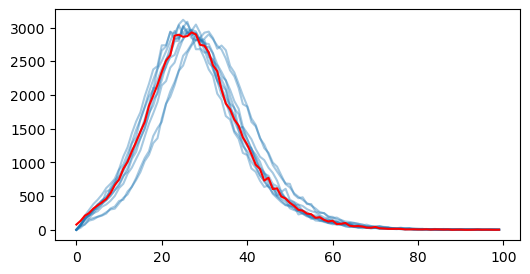

In [4]:
plt.subplots(figsize=(6,3))

observed_data = pd.read_csv('incidence_synthetic_curve.csv'
                           ).iloc[:100]
observed_data.columns=['incidence']

beta_arr = np.arange(0.1, 1, 0.01) #np.arange(0.04, 0.09, 0.01)
alpha_arr = np.arange(0.2, 1, 0.01) #np.arange(0.005, 0.011, 0.001)

i = 0
results=[]
for beta in beta_arr:
    beta = round(beta,2)
    for alpha in alpha_arr:
        alpha = round(alpha,2)
        #print(chosen.iloc[:,:2].values, beta, alpha)


        if (beta==true_tau)&(alpha==true_alpha):
            incidence = d.iloc[i*10:i*10+10,2:].values#.mean()
            for i in range(10):
                plt.plot(incidence[i][:100], color='tab:blue',
                        alpha=0.4, label='')
        i+=1
plt.plot(observed_data,color='red')

## hm

In [96]:
# create
network_params = {'n_nodes': 100000,
                  'network_type': 'ba'}
#observed_prv = observed_data[['incidence']]
hn = NetworkSEIR_tuned(observed_data, network_params,
                       fixed_sigma=gamma, 
                       fixed_gamma=delta)

'''

true_tau = 0.1
true_alpha = 0.95
'''
# define parameter ranges for priors
prior_ranges = {"tau": (0.57, 0.59),  
                "alpha": (0.79, 0.81) 
                }

start_time = time.time()
# run History Matching
hm_results = hn.history_matching(prior_ranges, 
                                 n_samples=7200,
                                 adaptive=True, 
                                 accept_ratio=.02,
                                 prepared=True, 
                                 folder='../hybrid_surrogate/sim_data/new_sw_100000/',
                                 file = 'data_ba_100000.csv')
end_time = time.time()

print('It took: ', end_time - start_time)

Network SEIR - Fixed parameters: sigma = 0.3, gamma = 0.2
Calibrating parameters
Running Network SEIR history matching with 7200 samples...
Accepted 144 parameter sets
It took:  5.553905487060547


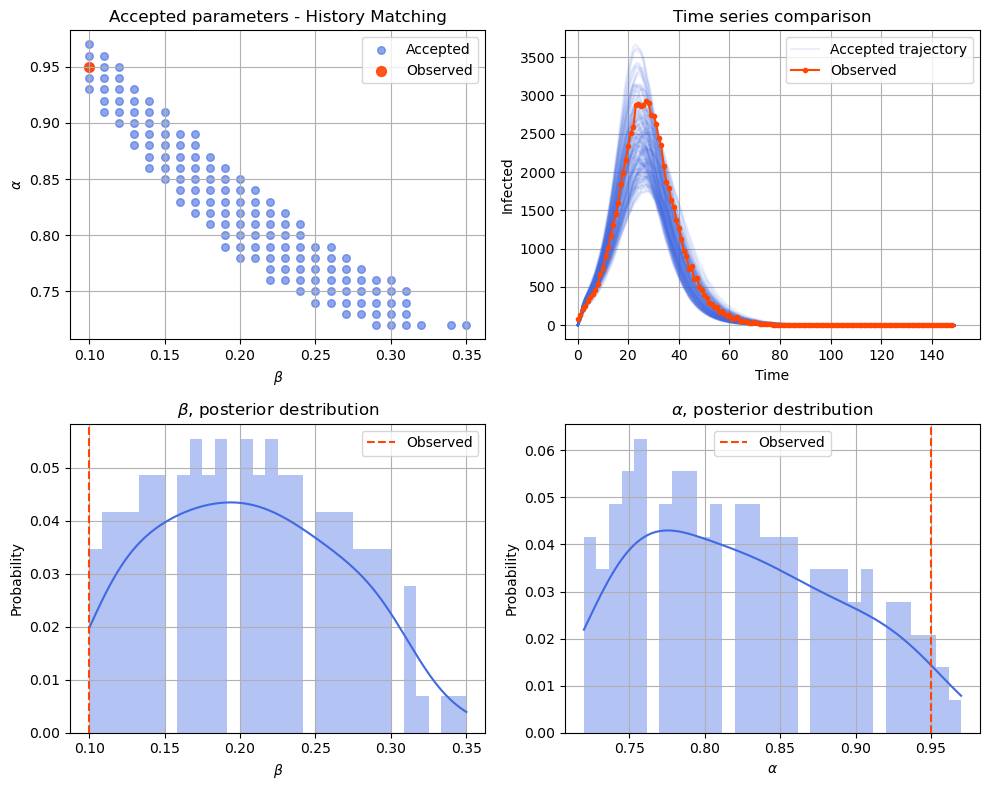

In [97]:
plot_results(observed_data, hm_results, 
             "History Matching", n_trajectories=len(hm_results),
             true_p0=true_tau, true_p1=true_alpha)

plt.savefig(f'results/hmba.pdf', format='pdf', bbox_inches='tight')

In [98]:
hm_results['tau'].quantile(.01), hm_results['tau'].quantile(.99)

(np.float64(0.1), np.float64(0.33139999999999986))

In [99]:
hm_results['tau'].min(), hm_results['tau'].max()

(np.float64(0.1), np.float64(0.35))

In [134]:
hm_results['alpha'].min(), hm_results['alpha'].max()

(np.float64(0.72), np.float64(0.97))

In [102]:
hm_results.head()

,tau,alpha,distance,trajectory
154,0.11,0.94,22.261074,"[0.0, 64.4, 167.5, 228.9, 292.4, 353.1, 414.4,..."
390,0.14,0.90,22.343624,"[0.0, 74.1, 185.5, 251.2, 307.8, 367.1, 434.3,..."
232,0.12,0.92,24.069799,"[0.0, 68.2, 167.7, 234.6, 289.8, 358.7, 400.8,..."
311,0.13,0.91,30.273826,"[0.0, 70.2, 177.3, 254.1, 332.1, 389.9, 447.6,..."
75,0.10,0.95,31.273826,"[0.0, 65.2, 149.8, 211.9, 266.7, 321.7, 375.3,..."


## checking

CPU times: total: 1min 6s
Wall time: 1min 6s


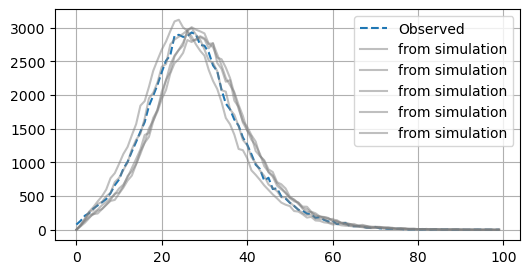

In [14]:
%%time
plt.subplots(figsize=(6,3))
plt.plot(observed_data.incidence, ls='--', label='Observed')

for i in range(5):
    # 0.1, 0.95
    q = calibr_funcs.simulation_func(_, tau=[0.1], 
                                     alpha=[0.95], 
                        modeling_duration=[observed_data.shape[0]], 

                        with_switch=False, num_runs=[1], 
                        frac=[1], size=[observed_data.shape[0]])

    
    plt.plot(q, label='from simulation',color='gray',alpha=.5)

plt.grid()
plt.legend()

[7.33267101e-06 7.12241282e-06 7.12241282e-06]
8
[1.23548368e-05 9.15874720e-06 9.15874720e-06]
7
[7.04150182e-06 7.46467602e-06 7.46467602e-06]
8
[9.56623638e-06 8.34689006e-06 8.34689006e-06]
8
[8.06599056e-06 7.37860139e-06 7.37860139e-06]
8
CPU times: total: 28 s
Wall time: 26.8 s


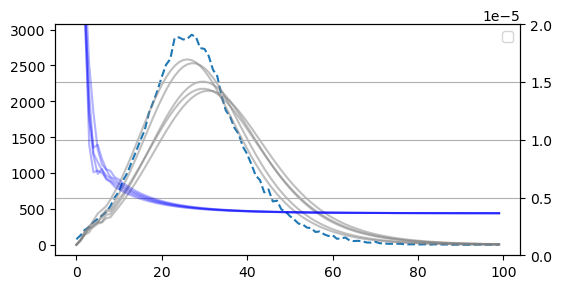

In [7]:
%%time
# 0.1, 0.95
fig, ax = plt.subplots(figsize=(6,3))
axb = ax.twinx()
ax.plot(observed_data.incidence, ls='--', label='Observed')

for i in range(5):
    # 0.1, 0.95
    q,df = calibr_funcs.simulation_func(_, tau=[0.1], 
                                     alpha=[0.95], 
                        modeling_duration=[observed_data.shape[0]], 

                        with_switch=True, num_runs=[1], 
                        frac=[.01], with_df=[True],
                                     size=[observed_data.shape[0]])

    
    ax.plot(q, label='from simulation',color='gray',alpha=.5)
    axb.plot(df.Beta, color='blue', alpha=0.3)


axb.set_ylim(0, 2e-5)    
plt.grid()
plt.legend()

[6.38372890e-06 6.60712665e-06 6.60712665e-06]
12
[6.59923956e-06 6.35539317e-06 6.35539317e-06]
14
[6.28710928e-06 6.36989549e-06 6.36989549e-06]
15
[6.40009238e-06 6.23706329e-06 6.23706329e-06]
15
[6.34263166e-06 6.40867839e-06 6.40867839e-06]
16
CPU times: total: 31 s
Wall time: 30 s


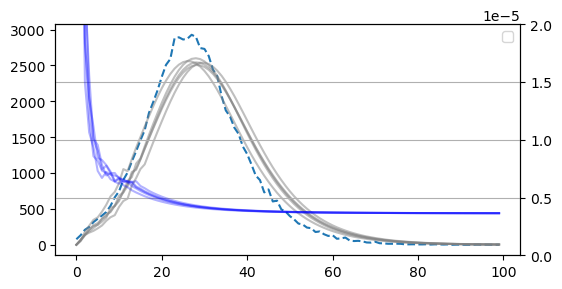

In [8]:
%%time
# 0.1, 0.95
fig, ax = plt.subplots(figsize=(6,3))
axb = ax.twinx()
ax.plot(observed_data.incidence, ls='--', label='Observed')

for i in range(5):
    # 0.1, 0.95
    q,df = calibr_funcs.simulation_func(_, tau=[0.1], 
                                     alpha=[0.95], 
                        modeling_duration=[observed_data.shape[0]], 

                        with_switch=True, num_runs=[1], 
                        frac=[.03], with_df=[True],
                                     size=[observed_data.shape[0]])

    
    ax.plot(q, label='from simulation',color='gray',alpha=.5)
    axb.plot(df.Beta, color='blue', alpha=0.3)


axb.set_ylim(0, 2e-5)    
plt.grid()
plt.legend()

[6.28946372e-06 5.96361227e-06 5.96361227e-06]
16
[6.19317811e-06 6.02568035e-06 6.02568035e-06]
16
[6.12306082e-06 5.96344702e-06 5.96344702e-06]
20
[6.15418290e-06 6.09432507e-06 6.09432507e-06]
17
[6.10662234e-06 5.89166524e-06 5.89166524e-06]
16
CPU times: total: 32.6 s
Wall time: 31.4 s


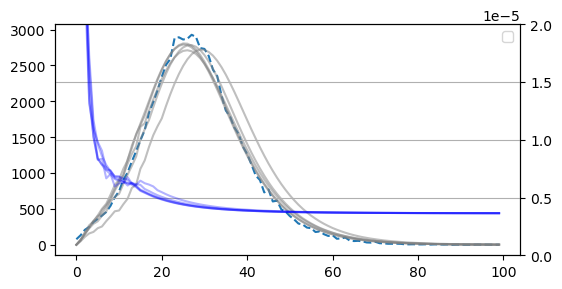

In [6]:
%%time
# 0.1, 0.95
fig, ax = plt.subplots(figsize=(6,3))
axb = ax.twinx()
ax.plot(observed_data.incidence, ls='--', label='Observed')

for i in range(5):
    # 0.1, 0.95
    q,df = calibr_funcs.simulation_func(_, tau=[0.1], 
                                     alpha=[0.95], 
                        modeling_duration=[observed_data.shape[0]], 

                        with_switch=True, num_runs=[1], 
                        frac=[.05], with_df=[True],
                                     size=[observed_data.shape[0]])

    
    ax.plot(q, label='from simulation',color='gray',alpha=.5)
    axb.plot(df.Beta, color='blue', alpha=0.3)


axb.set_ylim(0, 2e-5)    
plt.grid()
plt.legend()

(0.0, 2e-05)

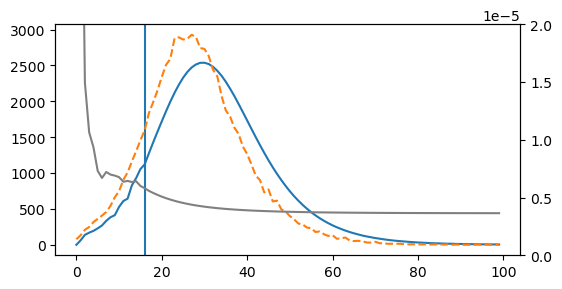

In [13]:
fig, ax = plt.subplots(figsize=(6,3))
axb = ax.twinx()
df.incidence.plot(ax=ax)
ax.axvline(16)

ax.plot(observed_data.incidence, ls='--', label='Observed')
axb.plot(df.Beta, color='gray')
axb.set_ylim(0,2e-5)

In [28]:
(5008.0-5507)-(78937.0-80537.0)

1101.0

## hybrid; hm

In [ ]:

# 671.4
draws = 30
chains = 3
progressbar = True

'''

'''

with_switch=np.array(True) 
num_runs=[3]
frac=[0.015]
gamma = 0.3
delta=0.2
n_nodes=100000


with pm.Model() as pm_model:
    #alpha_v = pm.Uniform(name="alpha", lower=0.6, upper=0.8375)
    #lmbd_v = pm.Uniform(name="lmbd", lower=0.325, upper=0.5)
    
    p0_v = pm.Uniform(name="tau", 
                      lower=hm_results['tau'].min(),#quantile(.01), 
                      upper=hm_results['tau'].max()#quantile(.99)
                     )
    p1_v = pm.Uniform(name="alpha", 
                      lower=hm_results['alpha'].min(),#quantile(.01), 
                      upper=hm_results['alpha'].max()#quantile(.99)
                     )
    # вынесем, тк для прогноза нужно будет задавать размер
    modeling_duration = len(observed_data) #149
    

    sim = pm.Simulator("sim", simulation_func, 
                        params = (p0_v, p1_v, modeling_duration, 
                                  with_switch, num_runs, frac
                                 ),   
                       
                        epsilon=2000, 
                        #ndims_params=[1,1,1,1,1,1],
                        observed=observed_data['incidence'].values
                      )
    
    # maybe parameter start == mean of HM ?
    #step=pm.DEMetropolisZ()
    
    start_time = time.time()
    idata = pm.sample_smc(#tune=tune, 
                          draws=draws, 
                          cores=6, chains=chains,
                          #step=step, 
                          progressbar=progressbar)
    end_time = time.time()
    
    idata.extend(pm.sample_posterior_predictive(idata,
                                            progressbar=progressbar))

    

# ~40-50 sec per sample
# 4472sec, 2x100, frac=0.01
print('It took ', end_time-start_time, 'sec')

Initializing SMC sampler...
Sampling 3 chains in 3 jobs


In [ ]:
plot_funcs.plots(idata, observed_data['incidence'].values, '', 
                 for_pred=False, with_trace=True)


In [ ]:
plot_funcs.results_calib(observed_data, idata, 
                         true_tau, true_alpha)
plt.savefig(f'results/ba_calib.pdf', format='pdf', bbox_inches='tight')

## network, no hm

In [168]:
19600/60/60

5.444444444444445

In [30]:
# 851.69

draws = 150
chains = 3
progressbar = True

'''

'''

with_switch=np.array(False) 
with_df=[False]
num_runs=[1]
frac=[1]
gamma = 0.3
delta=0.2
n_nodes=100000

network_params=[with_switch,num_runs,frac,gamma,delta,n_nodes]

with pm.Model() as pm_model_t:
    #alpha_v = pm.Uniform(name="alpha", lower=0.6, upper=0.8375)
    #lmbd_v = pm.Uniform(name="lmbd", lower=0.325, upper=0.5)
    real_data = pm.Data("incidence", observed_data['incidence'].values)
    p0_v = pm.Uniform(name="tau", lower=0., upper=1.)
    p1_v = pm.Uniform(name="alpha", lower=0., upper=1.)
    # вынесем, тк для прогноза нужно будет задавать размер
    modeling_duration = len(observed_data) #149
    

    sim = pm.Simulator("sim", calibr_funcs.simulation_func, 
                        params = (p0_v, p1_v, modeling_duration, 
                                  with_switch, num_runs, frac,
                                  with_df
                                 ),   
                       
                       
                        epsilon=2000, 
                        #ndims_params=[1,1,1,1,1,1],
                        observed=real_data
                      )
    
    # maybe parameter start == mean of HM ?
    #step=pm.DEMetropolisZ()
    
    start_time = time.time()
    idata2 = pm.sample_smc(#tune=tune, 
                          draws=draws, 
                          cores=6, chains=chains,
                          #step=step, 
                          progressbar=progressbar)
    end_time = time.time()
    
    idata2.extend(pm.sample_posterior_predictive(idata2,
                                            progressbar=progressbar))

    

# It took  32616.331862449646 sec
print('It took ', end_time-start_time, 'sec')

Initializing SMC sampler...
Sampling 3 chains in 3 jobs


We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [sim]


It took  32616.331862449646 sec


In [83]:
with_switch=np.array(False) 
with_df=[False]
num_runs=[1]
frac=[1]
gamma = 0.3
delta=0.2
n_nodes=100000

network_params=[with_switch,num_runs,frac,gamma,delta,n_nodes]

In [82]:
plot_funcs.plots(idata2, observed_data['incidence'].values, '', 
                 for_pred=False, with_trace=True,
                 network_params=network_params)


0 0
False


IndexError: too many indices for array: array is 0-dimensional, but 1 were indexed

0.18 0.84


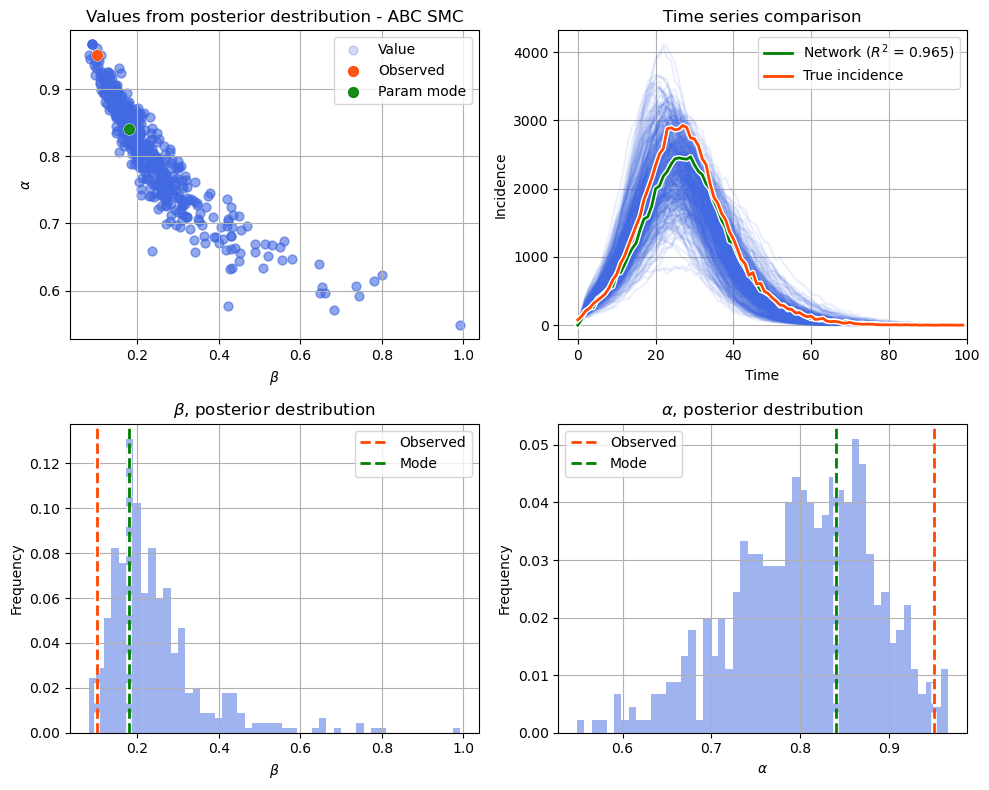

In [97]:
plot_funcs.results_calib(observed_data, idata2, 
                         true_tau, true_alpha,
                        network_params=network_params)

In [111]:
idata2.posterior.stack(samples=("draw", "chain")
                      )

<xarray.Dataset> Size: 18kB
Dimensions:  (samples: 450)
Coordinates:
  * samples  (samples) object 4kB MultiIndex
  * draw     (samples) int64 4kB 0 0 0 1 1 1 2 2 ... 147 148 148 148 149 149 149
  * chain    (samples) int64 4kB 0 1 2 0 1 2 0 1 2 0 1 ... 1 2 0 1 2 0 1 2 0 1 2
Data variables:
    tau      (samples) float64 4kB 0.08968 0.2819 0.4268 ... 0.1751 0.2416
    alpha    (samples) float64 4kB 0.9665 0.7132 0.6318 ... 0.7686 0.8729 0.7397
Attributes:
    created_at:                 2025-09-05T06:11:51.441304+00:00
    arviz_version:              0.22.0
    inference_library:          pymc
    inference_library_version:  5.25.1

In [116]:
p1

<xarray.DataArray 'alpha' (samples: 450)> Size: 4kB
array([0.96645851, 0.71322643, 0.63184922, 0.96645851, 0.90536329,
       0.81127191, 0.96645851, 0.83046419, 0.7623195 , 0.96645851,
       0.79010843, 0.8055519 , 0.91588703, 0.79540179, 0.75204025,
       0.68034277, 0.6342515 , 0.78824538, 0.69668568, 0.86867953,
       0.7295972 , 0.76211727, 0.8934039 , 0.78420995, 0.74184122,
       0.71139096, 0.80398744, 0.85333034, 0.74730271, 0.84815582,
       0.87804436, 0.65963404, 0.81570033, 0.8684811 , 0.75195945,
       0.83588565, 0.87950149, 0.91852278, 0.75825996, 0.86724733,
       0.81999674, 0.83464459, 0.77513994, 0.68096155, 0.81196182,
       0.89780101, 0.84560575, 0.66038181, 0.94953767, 0.86242879,
       0.69153224, 0.75172462, 0.75843455, 0.8540216 , 0.92541311,
       0.60566394, 0.66917976, 0.71527205, 0.85810144, 0.85515367,
       0.93645318, 0.93136665, 0.66319002, 0.83878451, 0.85039631,
       0.78470825, 0.87117083, 0.79506968, 0.74238301, 0.88429174,
       0.69797634, 0.79309975, 0.72806832, 0.86657685, 0.83195459,
       0.84441474, 0.74082675, 0.73427544, 0.69435576, 0.80966611,
       0.82111119, 0.68984401, 0.80245271, 0.77604051, 0.85740063,
       0.77675241, 0.68157627, 0.74425589, 0.86886085, 0.81098706,
       0.81954196, 0.81018709, 0.84199959, 0.79280701, 0.85797101,
       0.60717167, 0.7219942 , 0.74466552, 0.66561091, 0.83036705,
...
       0.82919797, 0.91093949, 0.84018392, 0.86830288, 0.79194933,
       0.90163757, 0.8213407 , 0.74041066, 0.78982835, 0.86393877,
       0.83968753, 0.81325674, 0.81592305, 0.80522998, 0.69568605,
       0.79493933, 0.92493783, 0.86990868, 0.85229493, 0.90337895,
       0.80285866, 0.84159279, 0.74214667, 0.80940674, 0.78263477,
       0.86970154, 0.87869741, 0.80926546, 0.86638433, 0.72375698,
       0.89339671, 0.71380529, 0.7820666 , 0.86227358, 0.84953236,
       0.73634108, 0.80408609, 0.95120417, 0.75717416, 0.76244245,
       0.8822922 , 0.73420955, 0.78944741, 0.73823312, 0.81139245,
       0.71253195, 0.81608982, 0.87591253, 0.83837756, 0.79911836,
       0.84655304, 0.67512476, 0.86004799, 0.83348174, 0.79127236,
       0.75254285, 0.8201103 , 0.80605548, 0.82486805, 0.86928835,
       0.81333406, 0.74734375, 0.7507647 , 0.86637672, 0.83720791,
       0.87602717, 0.74775646, 0.83961208, 0.64016458, 0.69402101,
       0.85791485, 0.75887975, 0.82049492, 0.81715686, 0.7271916 ,
       0.85776192, 0.75417234, 0.81779106, 0.87178788, 0.70890309,
       0.82492904, 0.83632516, 0.78436992, 0.73701653, 0.86265588,
       0.8585781 , 0.77092909, 0.7818345 , 0.91630644, 0.91587552,
       0.72523315, 0.93385737, 0.84702115, 0.76666105, 0.80268481,
       0.7648865 , 0.73281754, 0.76863421, 0.8729237 , 0.73969302])
Coordinates:
  * samples  (samples) object 4kB MultiIndex
  * draw     (samples) int64 4kB 0 0 0 1 1 1 2 2 ... 147 148 148 148 149 149 149
  * chain    (samples) int64 4kB 0 1 2 0 1 2 0 1 2 0 1 ... 1 2 0 1 2 0 1 2 0 1 2

In [127]:
p0 = idata2.posterior.stack(samples=("draw", "chain")
                      )['tau']
p1 = idata2.posterior.stack(samples=("draw", "chain")
                      )['alpha']

p01 = pd.DataFrame([p0.values,p1.values]).T.values
p01[:5]

array([[0.08967923, 0.96645851],
       [0.28186319, 0.71322643],
       [0.42675767, 0.63184922],
       [0.08967923, 0.96645851],
       [0.12110572, 0.90536329]])

In [194]:
from collections import Counter

counts = Counter(tuple(s) for s in p01.round(2))
result = [[k[0],k[1],v] for k, v in counts.items()]
result[:5]

[[np.float64(0.09), np.float64(0.97), 4],
 [np.float64(0.28), np.float64(0.71), 1],
 [np.float64(0.43), np.float64(0.63), 2],
 [np.float64(0.12), np.float64(0.91), 3],
 [np.float64(0.21), np.float64(0.81), 3]]

In [217]:
pd.DataFrame(result).sort_values(2, ascending=False)

,0,1,2
29,0.15,0.87,7
118,0.18,0.84,7
24,0.19,0.85,6
57,0.19,0.84,6
41,0.18,0.85,6
...,...,...,...
238,0.26,0.73,1
239,0.23,0.77,1
240,0.22,0.80,1
241,0.34,0.73,1


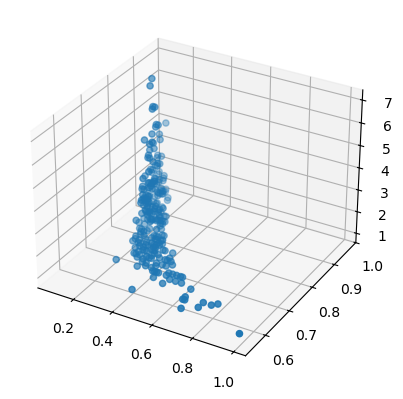

In [232]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(np.array(result)[:,0],
          np.array(result)[:,1],
          np.array(result)[:,2])
#ax.view_init(30, 30)

In [2]:
import plotly.express as px

In [6]:
df = px.data.iris()
fig = px.scatter_3d(df, x='sepal_length', y='sepal_width', z='petal_width',
              color='species')
fig.show()

In [95]:
import scipy.stats as stats
stats.mode(idata2.posterior.stack(samples=("draw", "chain")
                      )['tau'].round(2))

ModeResult(mode=np.float64(0.18), count=np.int64(33))

In [96]:
stats.mode(idata2.posterior.stack(samples=("draw", "chain")
                      )['alpha'].round(2))

ModeResult(mode=np.float64(0.84), count=np.int64(25))

In [33]:
idata = idata2.copy()

# for string
idata.sample_stats['beta'] = idata.sample_stats['beta'].astype(str)

#idata.to_netcdf(f"ba_net_{draws}_{chains}.nc")

'ba_net_150_3.nc'

## hybrid, no hm

In [26]:

# 
draws = 150
chains = 3
progressbar = True

'''

'''

with_switch=np.array(True) 
with_df=np.array(False) 
num_runs=[1]
frac=[0.05]
gamma = 0.3
delta=0.2
n_nodes=100000

network_params=[with_switch,num_runs,frac,gamma,delta,n_nodes]

with pm.Model() as pm_model_t:
    #alpha_v = pm.Uniform(name="alpha", lower=0.6, upper=0.8375)
    #lmbd_v = pm.Uniform(name="lmbd", lower=0.325, upper=0.5)
    real_data = pm.Data("incidence", observed_data['incidence'].values)
    p0_v = pm.Uniform(name="tau", lower=0., upper=1.)
    p1_v = pm.Uniform(name="alpha", lower=0., upper=1.)
    # вынесем, тк для прогноза нужно будет задавать размер
    modeling_duration = len(observed_data) #149
    

    sim = pm.Simulator("sim", calibr_funcs.simulation_func, 
                        params = (p0_v, p1_v, modeling_duration, 
                                  with_switch, num_runs, frac,
                                 with_df),   
                       
                        epsilon=2000, 
                        #ndims_params=[1,1,1,1,1,1],
                        observed=real_data
                      )
    
    # maybe parameter start == mean of HM ?
    #step=pm.DEMetropolisZ()
    
    start_time = time.time()
    idatat = pm.sample_smc(#tune=tune, 
                          draws=draws, 
                          cores=None, 
                          chains=chains,
                          #step=step, 
                          progressbar=progressbar)
    end_time = time.time()
    
    idatat.extend(pm.sample_posterior_predictive(idatat,
                                            progressbar=progressbar))

    

# It took  19319.201872587204 sec
print('It took ', end_time-start_time, 'sec')

Initializing SMC sampler...
Sampling 3 chains in 3 jobs


We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [sim]


It took  19319.201872587204 sec


In [98]:
with_switch=np.array(True) 
with_df=np.array(False) 
num_runs=[1]
frac=[0.05]
gamma = 0.3
delta=0.2
n_nodes=100000

network_params=[with_switch,num_runs,frac,gamma,delta,n_nodes]

In [71]:
plot_funcs.plots(idatat, observed_data['incidence'].values, '', 
                 for_pred=False, with_trace=True, 
                 network_params=network_params)


0 0


AssertionError: Incorrect initial conditions, immune + infected > population size!

0.13 0.86


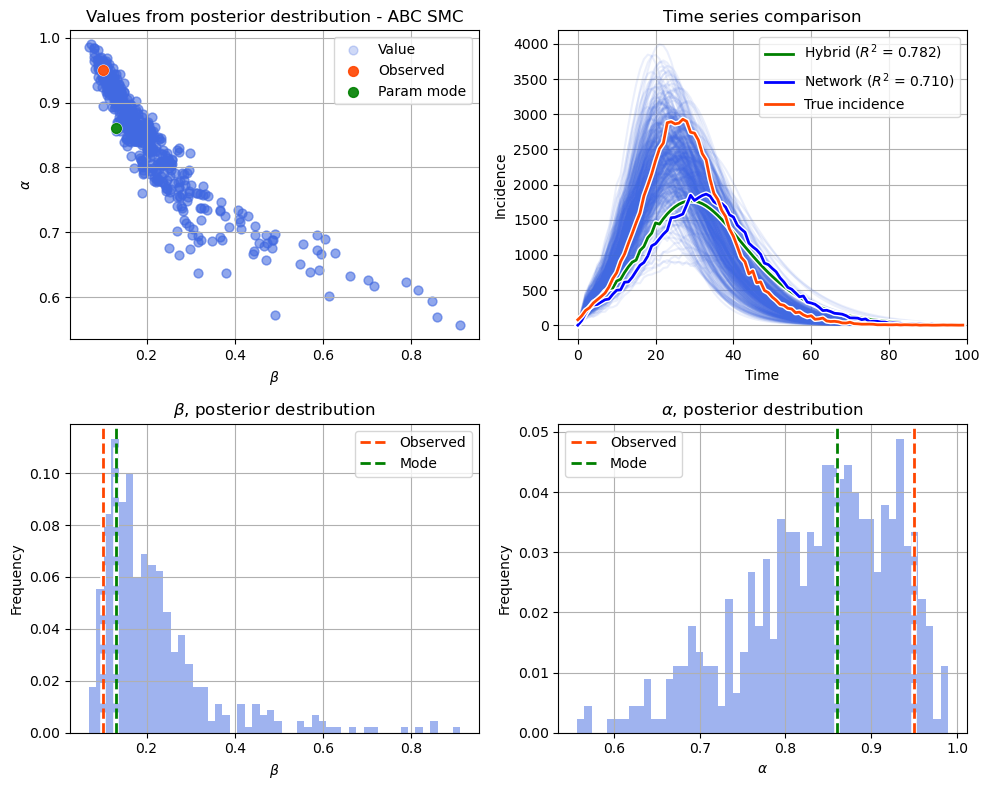

In [100]:
plot_funcs.results_calib(observed_data, idatat, 
                         true_tau, true_alpha, network_params)

In [29]:
idata = idatat.copy()

# for string
idata.sample_stats['beta'] = idata.sample_stats['beta'].astype(str)

#idata.to_netcdf(f"ba_hyb_{draws}_{chains}_s3_r3.nc")

'ba_hyb_150_3_s3_r3.nc'

In [21]:
idata0 = az.from_netcdf(f"ba_hyb_{draws}_{chains}_s3_r3.nc")
idata0

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data
	> constant_data

In [128]:
idata0

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data
	> constant_data

## old

In [61]:
# 85 sec for 5x2, frac=0.01

draws = 200
chains = 3
progressbar = True

'''

'''

with_switch=np.array(True) 
num_runs=[2]
frac=[0.01]
gamma = 0.3
delta=0.2
n_nodes=100000


with pm.Model() as pm_model:
    #alpha_v = pm.Uniform(name="alpha", lower=0.6, upper=0.8375)
    #lmbd_v = pm.Uniform(name="lmbd", lower=0.325, upper=0.5)
    
    p0_v = pm.Uniform(name="tau", 
                      lower=hm_results['tau'].quantile(.01), 
                      upper=hm_results['tau'].quantile(.99)
                     )
    p1_v = pm.Uniform(name="alpha", 
                      lower=hm_results['alpha'].quantile(.01), 
                      upper=hm_results['alpha'].quantile(.99)
                     )
    # вынесем, тк для прогноза нужно будет задавать размер
    modeling_duration = len(observed_data) #249
    

    sim = pm.Simulator("sim", simulation_func, 
                        params = (p0_v, p1_v, modeling_duration, 
                                  with_switch, num_runs, frac
                                 ),   
                       
                        epsilon=3000, 
                        ndims_params=[1,1,1,1,1,1],
                        observed=observed_data['incidence'].values)
    
    # maybe parameter start == mean of HM ?
    #step=pm.DEMetropolisZ()
    
    start_time = time.time()
    idata = pm.sample_smc(#tune=tune, 
                          draws=draws, 
                          cores=6, chains=chains,
                          #step=step, 
                          progressbar=progressbar)
    end_time = time.time()
    
    idata.extend(pm.sample_posterior_predictive(idata,
                                            progressbar=progressbar))


# 10.5sec, 2x2, frac=0.001    
# 4472sec, 2x100, frac=0.01
print('It took ', end_time-start_time, 'sec')

Initializing SMC sampler...
Sampling 3 chains in 3 jobs


We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [sim]


It took  15549.978916406631 sec


[autoreload of cutils_ext failed: Traceback (most recent call last):
  File "C:\Users\MKoshkareva\anaconda3\envs\pymc_env\Lib\site-packages\IPython\extensions\autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\MKoshkareva\anaconda3\envs\pymc_env\Lib\site-packages\IPython\extensions\autoreload.py", line 580, in superreload
    module = reload(module)
  File "C:\Users\MKoshkareva\anaconda3\envs\pymc_env\Lib\importlib\__init__.py", line 128, in reload
    raise ModuleNotFoundError(f"spec not found for the module {name!r}", name=name)
ModuleNotFoundError: spec not found for the module 'cutils_ext'
]


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
tau,0.288,0.099,0.122,0.465,0.004,0.002,511.0,516.0,1.00
alpha,0.804,0.082,0.678,0.953,0.004,0.002,494.0,439.0,1.01


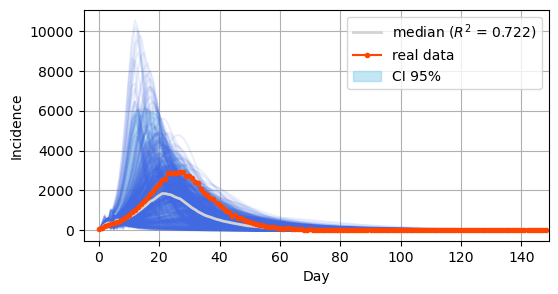

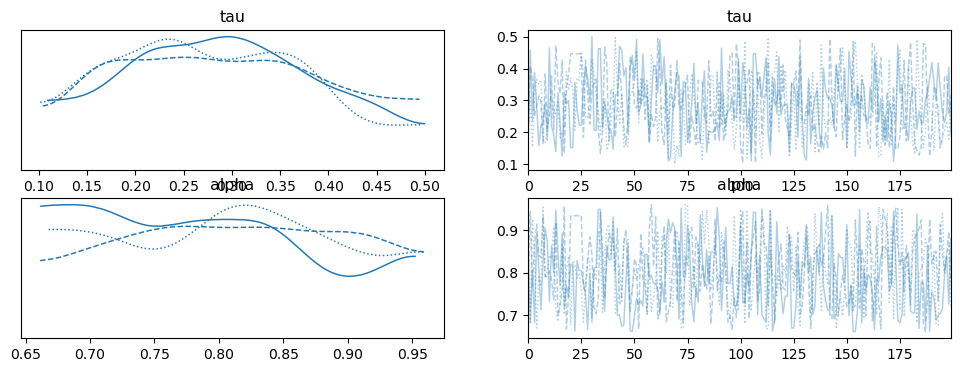

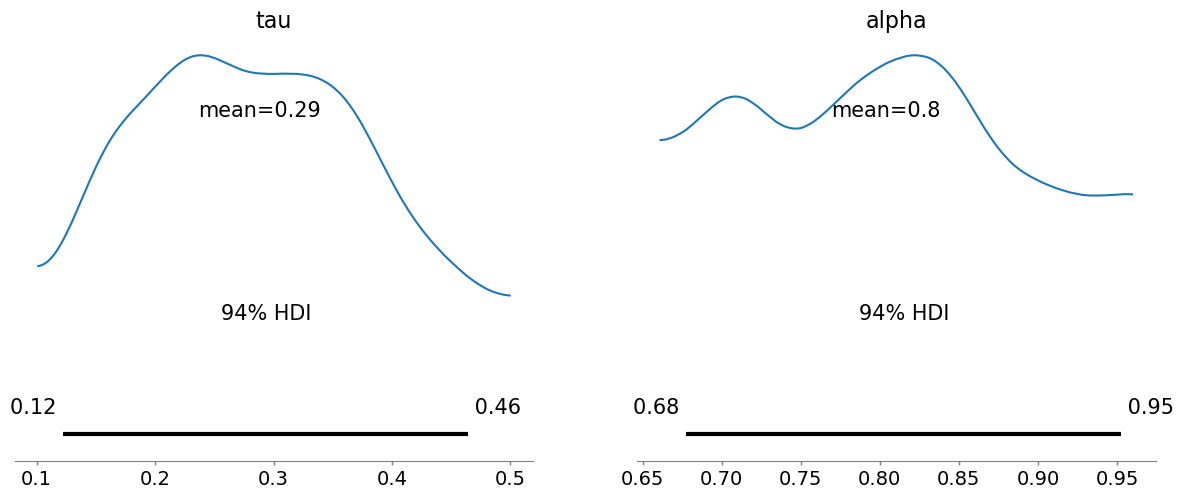

In [62]:
plot_funcs.plots(idata, observed_data['incidence'].values, '', 
                 simulation_func, for_pred=False, with_trace=True)


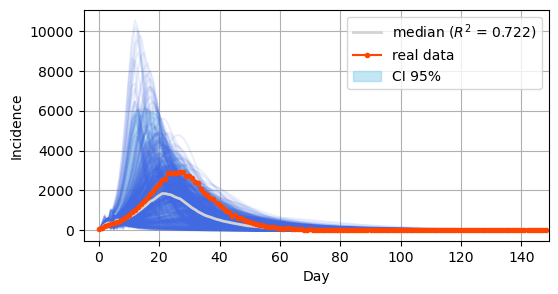

In [63]:
plot_funcs.plots(idata, observed_data['incidence'].values, '', 
                 simulation_func, for_pred=False, with_trace=False)
plt.savefig(f'results/ba_calib.pdf', format='pdf', bbox_inches='tight')

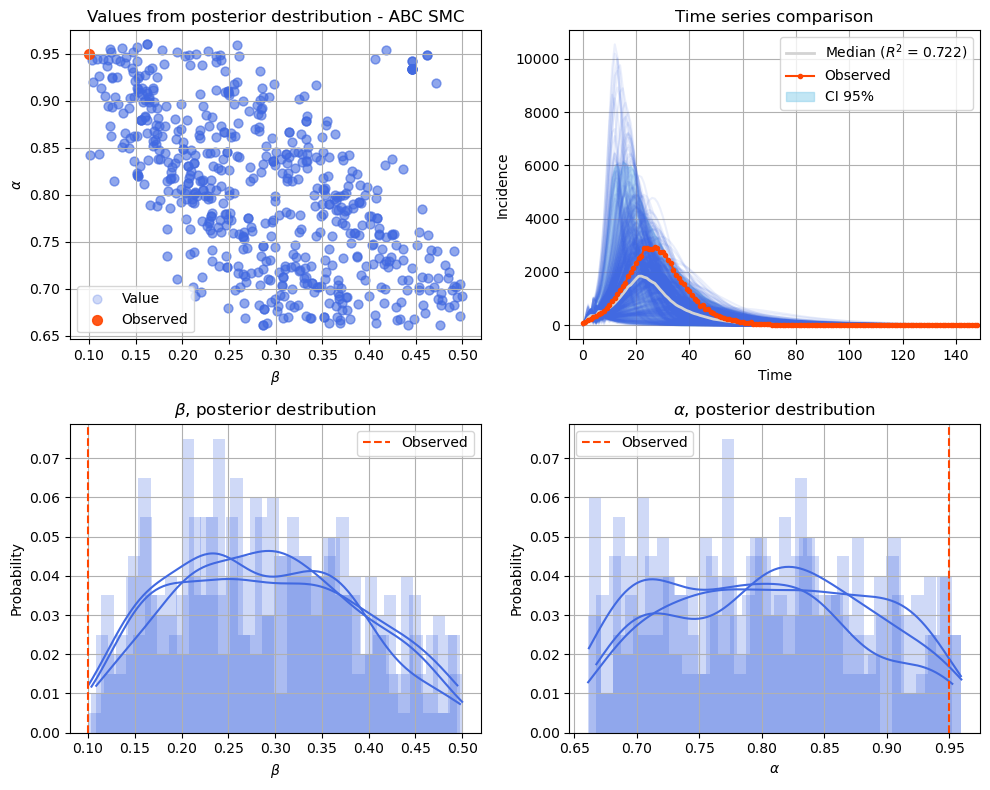

In [65]:
plot_funcs.results_calib(observed_data, idata, 
                         true_tau, true_alpha)
plt.savefig(f'results/ba_calib.pdf', format='pdf', bbox_inches='tight')

In [66]:
idata.posterior.to_netcdf('ba_p.h5', engine='scipy')
idata.posterior_predictive.to_netcdf('ba_pp.h5', engine='scipy')

[autoreload of cutils_ext failed: Traceback (most recent call last):
  File "C:\Users\MKoshkareva\anaconda3\envs\pymc_env\Lib\site-packages\IPython\extensions\autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\MKoshkareva\anaconda3\envs\pymc_env\Lib\site-packages\IPython\extensions\autoreload.py", line 580, in superreload
    module = reload(module)
  File "C:\Users\MKoshkareva\anaconda3\envs\pymc_env\Lib\importlib\__init__.py", line 128, in reload
    raise ModuleNotFoundError(f"spec not found for the module {name!r}", name=name)
ModuleNotFoundError: spec not found for the module 'cutils_ext'
]


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
tau,0.743,0.089,0.596,0.927,0.013,0.006,46.0,71.0,1.18
alpha,0.796,0.053,0.708,0.869,0.008,0.004,45.0,31.0,1.06


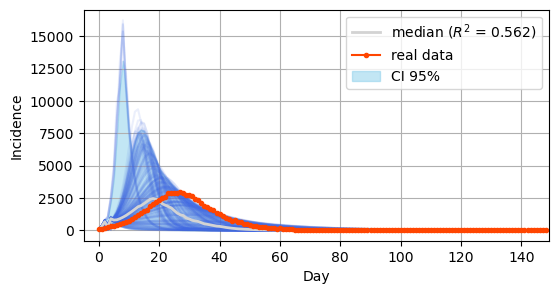

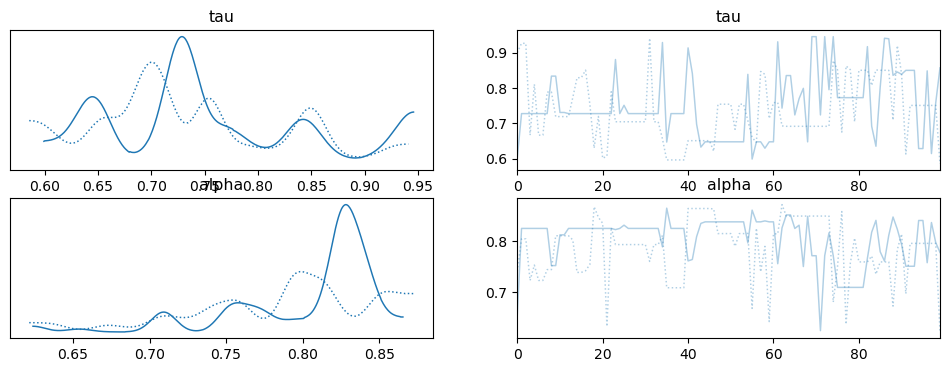

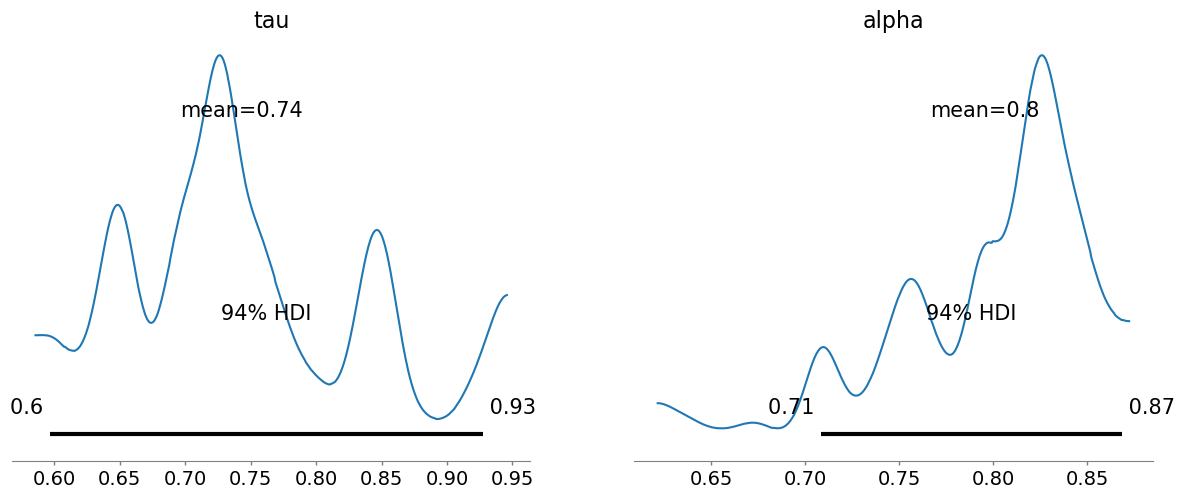

In [59]:
plot_funcs.plots(idata, observed_data['incidence'].values, '', 
                 simulation_func, for_pred=False, with_trace=True)
